# 2. Linear regression on house dataset
- Use this dataset on house price prediction in kaggle, 
- perform EDA on it and then predict the house prices using linear regression.
- You can drop the categorical features and the date columns. 
- Then try ElasticNetCV and RidgeCV on the same dataset. 
- Record the scores in a dataframe with the columns mae, mse, rmse so you can compare the models.

### EDA

In [1]:
import pandas as pd

df = pd.read_csv("../../data/data.csv")#) # make date column index and parse dates

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [2]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [4]:
df = df.drop(["date", "street", "city", "statezip", "country"], axis="columns")
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992


# inspecting values looking for 0 and extreme outliers

In [5]:
df["price"].sort_values().min()

np.float64(0.0)

In [6]:
df.shape

(4600, 13)

In [7]:
# remove all 0 vals in price
df = df[df["price"] > 0]

In [8]:
# checking low vals
df["price"].sort_values(ascending=True).head()

4351     7800.0
1219    80000.0
1587    83000.0
4407    83300.0
4415    83300.0
Name: price, dtype: float64

In [9]:
# checking high
df["price"].sort_values(ascending=False).head()

4350    26590000.0
4346    12899000.0
2286     7062500.0
2654     4668000.0
2761     4489000.0
Name: price, dtype: float64

### options for further testing with extreme outliers filtered

In [ ]:
# # calculating upper and lower limits by standard deviations and filtering out the outliers
# lower_limit = df["price"].mean() - 3 * df["price"].std()
# upper_limit = df["price"].mean() + 3 * df["price"].std()

# df = df[(df["price"] >= lower_limit) & (df["price"] <= upper_limit)]

# print(f"rows after filtering: {df.shape[0]} rows")

In [11]:
# # calculating upper and lower limits by percentiles and filtering out the outliers
# lower_limit = df["price"].quantile(0.01)
# upper_limit = df["price"].quantile(0.99)

# df = df[(df["price"] >= lower_limit) & (df["price"] <= upper_limit)]

# print(f"rows after filtering: {df.shape[0]} rows")
# print(f"lower : {lower_limit:,.0f}  |  upper: {upper_limit:,.0f}")


In [12]:
df.shape

(4551, 13)

In [ ]:
df.describe()

,count,mean,std,min,25%,50%,75%,max
price,4551.0,557905.899138,563929.871279,7800.0,326264.285715,465000.00,657500.0,26590000.0
bedrooms,4551.0,3.394639,0.904595,0.0,3.000000,3.00,4.0,9.0
bathrooms,4551.0,2.155021,0.776351,0.0,1.750000,2.25,2.5,8.0
sqft_living,4551.0,2132.372226,955.949708,370.0,1460.000000,1970.00,2610.0,13540.0
sqft_lot,4551.0,14835.280598,35964.077825,638.0,5000.000000,7680.00,10978.0,1074218.0
floors,4551.0,1.512195,0.538531,1.0,1.000000,1.50,2.0,3.5
waterfront,4551.0,0.006592,0.080932,0.0,0.000000,0.00,0.0,1.0
view,4551.0,0.234674,0.765373,0.0,0.000000,0.00,0.0,4.0
condition,4551.0,3.449352,0.675160,1.0,3.000000,3.00,4.0,5.0
sqft_above,4551.0,1822.221710,854.452888,370.0,1190.000000,1590.00,2300.0,9410.0


### divide X, y

In [14]:
X, y = df.drop("price", axis = "columns"), df["price"]
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992


In [15]:
y.head()

0     313000.0
1    2384000.0
2     342000.0
3     420000.0
4     550000.0
Name: price, dtype: float64

### Correlation heatmap for feat selection/ feat engineering
- checking correlations to determine what feats to eventually drop
- ex. drop those with high or low corr

<Axes: >

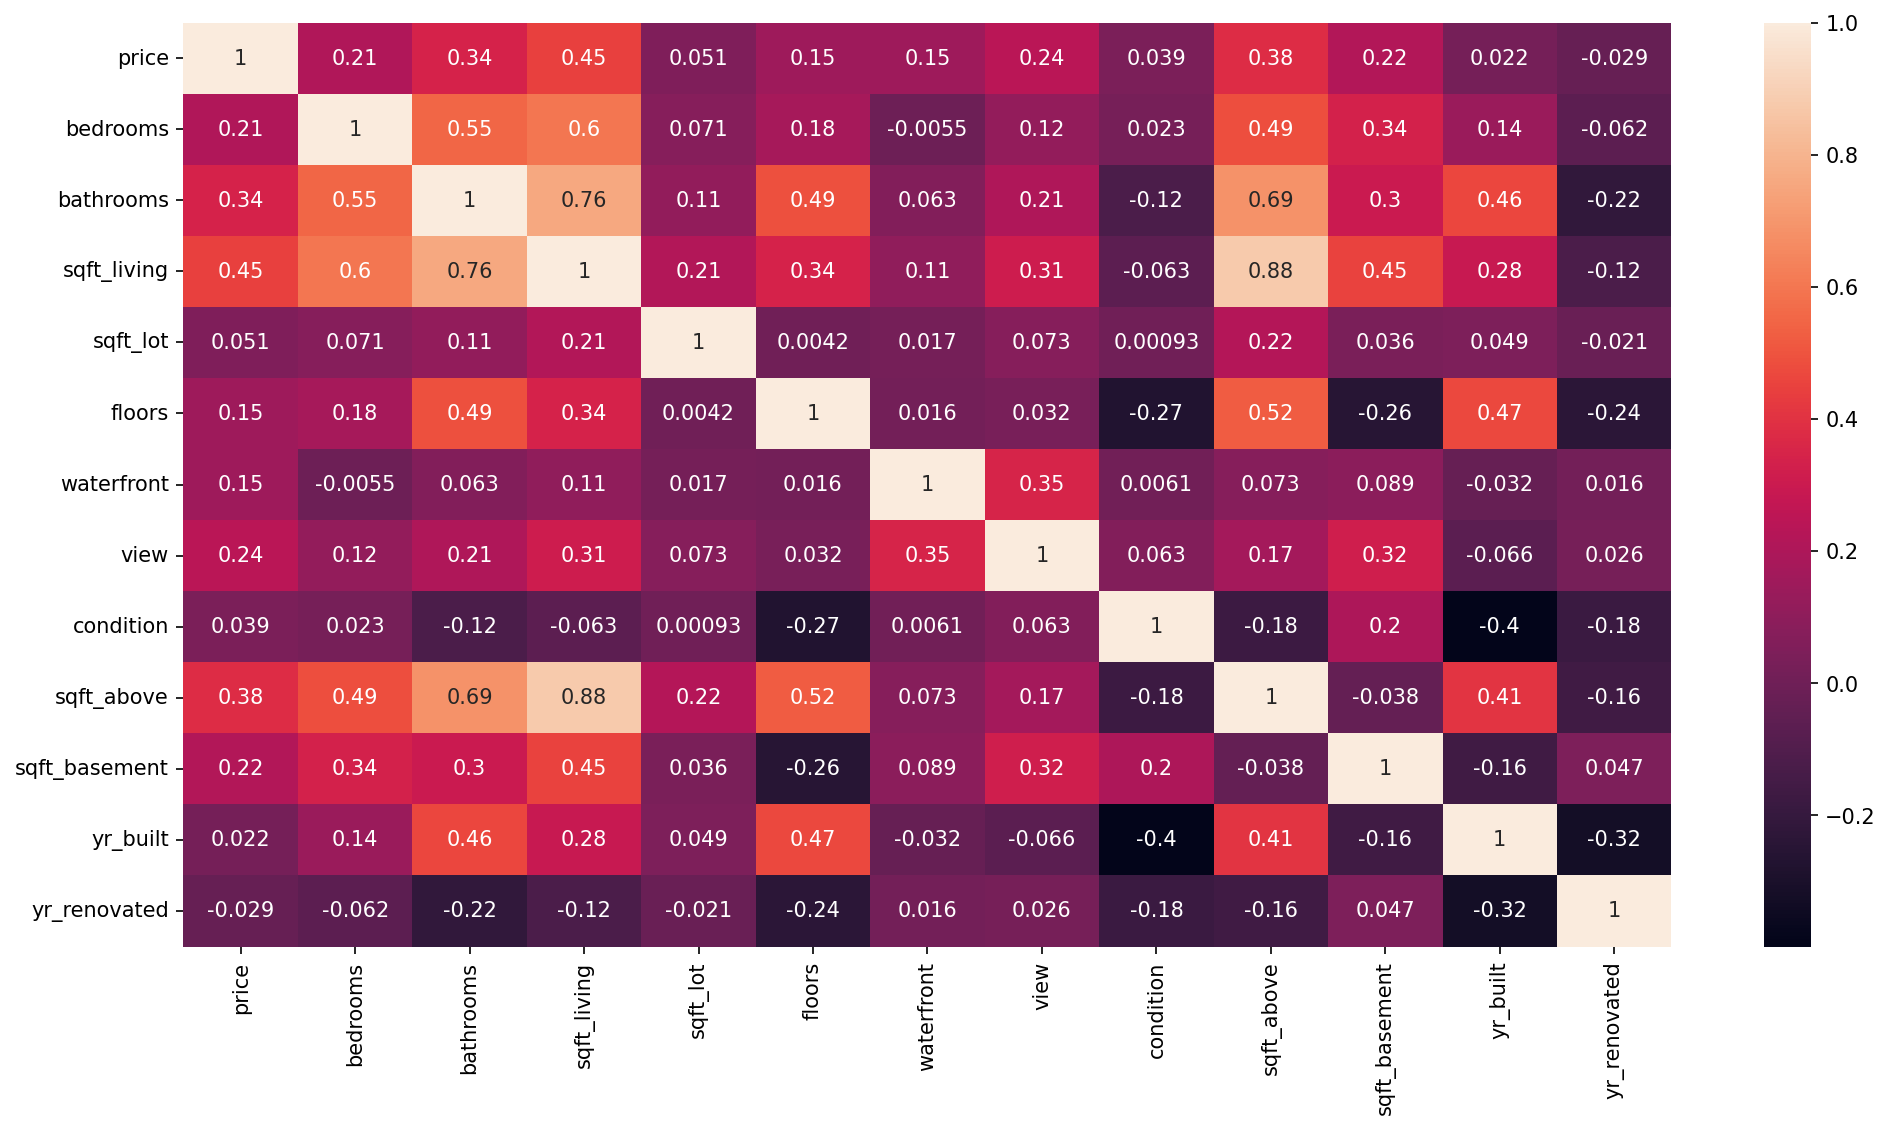

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig,ax = plt.subplots(1, figsize=(16,8), dpi=150)

sns.heatmap(df.corr(), annot=True)

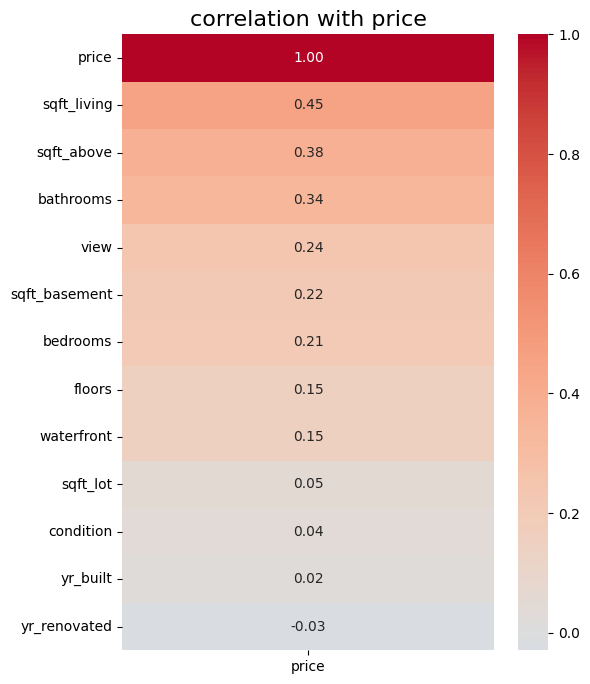

In [17]:
# merge X and y temporary
df_with_price = X.copy()
df_with_price["price"] = y

# Calc correlations. sort by price
corr_price = df_with_price.corr(numeric_only=True)[["price"]].sort_values(
    by="price", ascending=False
)

# visualize
plt.figure(figsize=(6, 8))
sns.heatmap(corr_price, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("correlation with price", fontsize=16)
plt.show()

## Linear regression

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

X_train.shape, y_train.shape

((3049, 12), (3049,))

### testing 2 types of scaling: MinMax and standard

In [19]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# scaler.fit(X_train)
# scaled_X_train = scaler.transform(X_train) 
# scaled_X_test = scaler.transform(X_test) 

# scaled_X_train.min(), scaled_X_train.max(), scaled_X_test.min(), scaled_X_test.max()

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
scaled_X_train = scaler.transform(X_train) 
scaled_X_test = scaler.transform(X_test) 

scaled_X_train.min(), scaled_X_train.max(), scaled_X_test.min(), scaled_X_test.max()

(np.float64(-3.7468293934934027),
 np.float64(29.481720895531357),
 np.float64(-3.611008266776248),
 np.float64(17.433910553624273))

In [21]:
from sklearn.linear_model import LinearRegression

model= LinearRegression()
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
model.fit(scaled_X_train, y_train)
model.coef_

array([-58914.01155502,  55822.55208177, 130685.38871054, -27834.78552674,
         9897.58147796,  37084.16235415,  39425.22087082,  31428.00187139,
       123109.51671601,  39961.0820985 , -70994.80298567,   6946.19161183])

In [23]:
model.intercept_

np.float64(563885.4278124447)

## Linear - prediction

In [24]:
test_sample_features = scaled_X_test[0].reshape(1, -1)
test_sample_target = y_test.values[0]
test_sample_features, test_sample_target


(array([[ 0.67511093,  3.06726711,  3.5094472 ,  2.42967554, -0.95746709,
         -0.07487897, -0.30352666, -0.66756108,  2.4463979 ,  2.67748162,
          1.03313568, -0.82111276]]),
 np.float64(1225000.0))

In [25]:
test_sample_features.shape

(1, 12)

In [26]:
test_sample_target

np.float64(1225000.0)

In [27]:
model.predict(test_sample_features)

array([1370257.4919046])

In [28]:
test_sample_target

np.float64(1225000.0)

### prediction on test data

In [29]:
y_pred = model.predict(scaled_X_test)
y_pred.shape

(1502,)

In [30]:
y_test.shape

(1502,)

In [31]:
y_pred[:5]

array([1370257.4919046 ,  608251.99107972,  657977.77818934,
        279447.06287658,  522732.44380393])

In [32]:
y_test[:5].values

array([1225000.,  496752.,  612500.,  265000.,  615000.])

### evaluation

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def metrics(y_test, y_pred):
    MSE = mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)
    MAE = mean_absolute_error(y_test, y_pred)

    return {"MSE": MSE, "MAE": MAE, "RMSE": RMSE}

metrics(y_test, y_pred)

{'MSE': 53255714398.187004,
 'MAE': 158370.37304234505,
 'RMSE': np.float64(230771.99656411304)}

### ridge_regression

In [34]:
from sklearn.linear_model import ElasticNetCV, RidgeCV

model_ridgeCV = RidgeCV(alphas=[.0001, .001, .01, .1, .5, 1, 5, 10], scoring="neg_mean_squared_error")
model_ridgeCV.fit(scaled_X_train, y_train)

model_ridgeCV.alpha_

np.float64(10.0)

In [35]:
y_pred = model_ridgeCV.predict(scaled_X_test)
metrics(y_test, y_pred)

{'MSE': 53212702836.396835,
 'MAE': 158279.42508212104,
 'RMSE': np.float64(230678.78714003338)}

In [36]:
model_ridgeCV.coef_

array([-58181.32863698,  55691.15972009, 130166.62441575, -27599.42948495,
        10030.17379053,  37060.09196888,  39525.16042177,  31410.6549112 ,
       122572.86205988,  39891.9721833 , -70515.62627721,   6989.42289946])

### lasso regression

In [37]:
from sklearn.linear_model import LassoCV
alphas = np.logspace(-3, 3, 50)
model_lassoCV = LassoCV(alphas=alphas, cv=5, max_iter=10000)
model_lassoCV.fit(scaled_X_train, y_train)

model_lassoCV.alpha_

np.float64(1000.0)

In [38]:
y_pred = model_lassoCV.predict(scaled_X_test)

metrics(y_test, y_pred)

{'MSE': 53135781061.75069,
 'MAE': 158106.15207526903,
 'RMSE': np.float64(230511.9976525098)}

In [39]:
model_lassoCV.coef_

array([-56047.60534799,  53752.01018142, 212551.06981708, -26560.30427823,
         8781.71861104,  36546.79213593,  39316.63428716,  29967.32685951,
        47395.27695284,      0.        , -69469.10605086,   5497.54725726])

### elastic NET regression

In [40]:
model_elastic = ElasticNetCV(
    l1_ratio=[.1, .5, .7, .9, .95, .99, 1], alphas=alphas, max_iter=10000
)
model_elastic.fit(scaled_X_train, y_train)
model_elastic.l1_ratio_

c:\Users\metal\Skola\course\ai_engineering_stefan_lundberg\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.269e+10, tolerance: 3.381e+10
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\metal\Skola\course\ai_engineering_stefan_lundberg\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.209e+11, tolerance: 1.188e+11
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\metal\Skola\course\ai_engineering_stefan_lundberg\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase

np.float64(0.9)

In [41]:
model_elastic.alpha_

np.float64(0.49417133613238334)

In [42]:
y_pred = model_elastic.predict(scaled_X_test)
metrics(y_test, y_pred)

{'MSE': 52779098336.44192,
 'MAE': 157201.29458277734,
 'RMSE': np.float64(229737.01995203542)}

In [43]:
model_elastic.coef_

array([-48967.70882959,  54091.4240263 , 123487.93640359, -24590.97553439,
        11579.37925711,  36670.90459424,  40654.77927027,  31016.52749045,
       115675.26870261,  38972.30560284, -64440.66243268,   7416.17810273])

### Record scores in DataFrame

In [44]:
# Calc errors for each model
mae_lin, mse_lin, rmse_lin = metrics(y_test, model.predict(scaled_X_test)).values()
mae_ridge, mse_ridge, rmse_ridge = metrics(y_test, model_ridgeCV.predict(scaled_X_test)).values()
mae_lasso, mse_lasso, rmse_lasso = metrics(y_test, model_lassoCV.predict(scaled_X_test)).values()
mae_elastic, mse_elastic, rmse_elastic = metrics(y_test, model_elastic.predict(scaled_X_test)).values()

# Create compare DataFrame
score_df = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "ElasticNet"],
    "MAE": [mae_lin, mae_ridge, mae_lasso, mae_elastic],
    "MSE": [mse_lin, mse_ridge, mse_lasso, mse_elastic],
    "RMSE": [rmse_lin, rmse_ridge, rmse_lasso, rmse_elastic]
})

print(score_df)

        Model           MAE            MSE           RMSE
0      Linear  5.325571e+10  158370.373042  230771.996564
1       Ridge  5.321270e+10  158279.425082  230678.787140
2       Lasso  5.313578e+10  158106.152075  230511.997653
3  ElasticNet  5.277910e+10  157201.294583  229737.019952


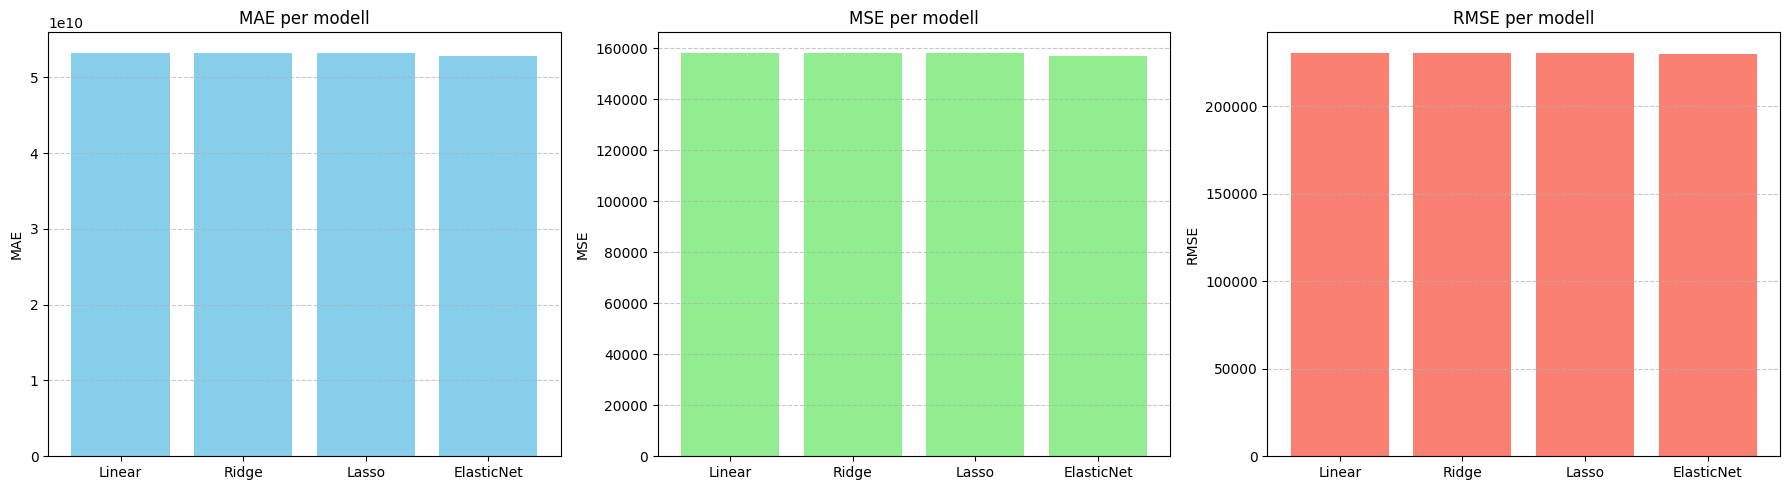

In [45]:
# bar chart for scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
axes[0].bar(score_df["Model"], score_df["MAE"], color="skyblue")
axes[0].set_title("MAE per modell")
axes[0].set_ylabel("MAE")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# MSE
axes[1].bar(score_df["Model"], score_df["MSE"], color="lightgreen")
axes[1].set_title("MSE per modell")
axes[1].set_ylabel("MSE")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# RMSE
axes[2].bar(score_df["Model"], score_df["RMSE"], color="salmon")
axes[2].set_title("RMSE per modell")
axes[2].set_ylabel("RMSE")
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()